In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

IMG_SIZE = (224, 224)
BATCH_SIZE = 32


# CUSTOM PREPROCESSING LAYER (fixes Lambda serialization issue)
@tf.keras.utils.register_keras_serializable()  # ← This makes it saveable/loadable
class ResNet50Preprocessor(layers.Layer):
    def call(self, x):
        return tf.keras.applications.resnet50.preprocess_input(x)

# LOAD DATA
train_ds = keras.utils.image_dataset_from_directory(
    r"data_processed/train",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = keras.utils.image_dataset_from_directory(
    r"data_processed/val",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
np.save("classes2.npy", class_names)
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

# MODEL (ResNet50)

base_model = keras.applications.ResNet50(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

model = keras.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),

    ResNet50Preprocessor(),  # ✅ Replaces layers.Lambda(...)

    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True, verbose=1)
    ]
)

model.save("waste_classifier_resnet50.keras")
print("✅ ResNet50 Model saved")





Found 7036 files belonging to 6 classes.
Using 5629 files for training.
Found 374 files belonging to 6 classes.
Using 74 files for validation.


Epoch 1/15


176/176 [==============================] - 123s 679ms/step - loss: 1.1310 - accuracy: 0.6037 - val_loss: 0.4398 - val_accuracy: 0.8649
Epoch 2/15
176/176 [==============================] - 122s 691ms/step - loss: 0.6503 - accuracy: 0.7724 - val_loss: 0.3487 - val_accuracy: 0.8919
Epoch 3/15
176/176 [==============================] - 127s 723ms/step - loss: 0.5550 - accuracy: 0.8060 - val_loss: 0.3513 - val_accuracy: 0.8784
Epoch 4/15
176/176 [==============================] - 122s 691ms/step - loss: 0.4657 - accuracy: 0.8437 - val_loss: 0.3542 - val_accuracy: 0.8919
Epoch 4: early stopping
✅ ResNet50 Model saved


Loading test dataset...
Found 382 files belonging to 6 classes.
Loading model...


Running evaluation on test data...


12/12 [==============================] - 20s 1s/step - loss: 0.5311 - accuracy: 0.8168
------------------------------
Test Loss:     0.5311
Test Accuracy: 81.68%
------------------------------

Generating detailed classification report...
12/12 [==============================] - 17s 1s/step

Classification Report:
              precision    recall  f1-score   support

   cardboard       0.87      0.91      0.89        65
       glass       0.88      0.82      0.85        62
       metal       0.80      0.91      0.85        66
       paper       0.88      0.78      0.83        65
     plastic       0.72      0.73      0.73        60
       trash       0.76      0.73      0.75        64

    accuracy                           0.82       382
   macro avg       0.82      0.82      0.82       382
weighted avg       0.82      0.82      0.82       382

Plotting Confusion Ma

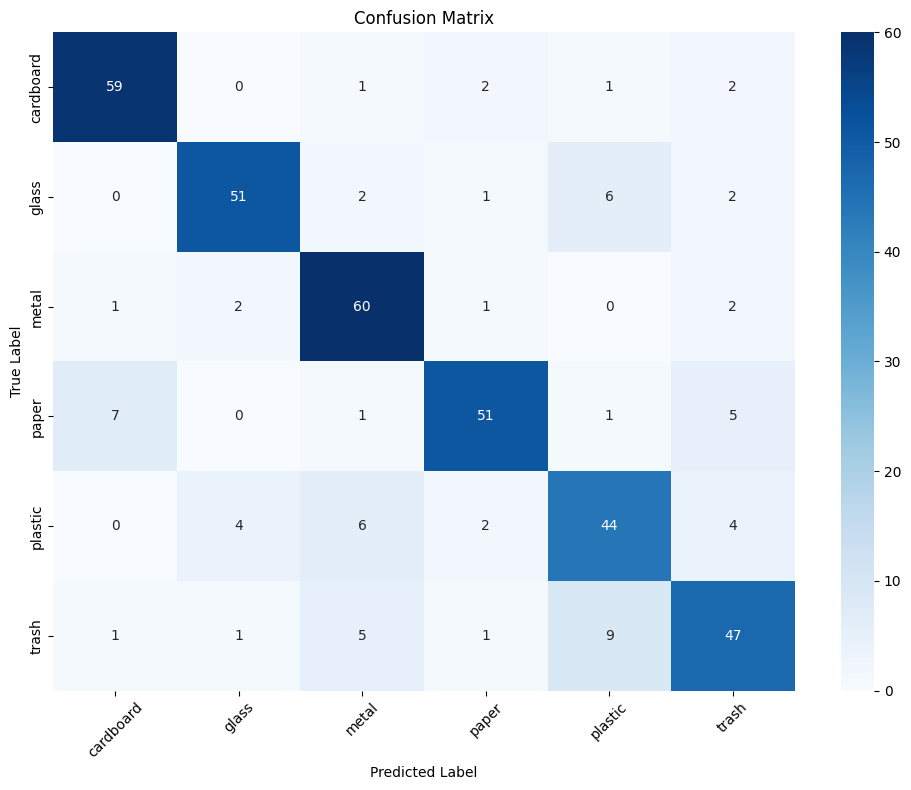

In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras import layers

# CUSTOM PREPROCESSING LAYER (required to load the model)
@tf.keras.utils.register_keras_serializable()
class ResNet50Preprocessor(layers.Layer):
    def call(self, x):
        return tf.keras.applications.resnet50.preprocess_input(x)

# =========================
# 1. SETUP & PATHS
# =========================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Update this path to where your test folder is located
TEST_DIR = r"F:\projects gam3a\Smart-Waste-Classification-NN-PROJECT-\data_processed\test"
MODEL_PATH = "waste_classifier_resnet50.keras"
CLASSES_PATH = r"F:\projects gam3a\Smart-Waste-Classification-NN-PROJECT-\classes2.npy"

# =========================
# 2. LOAD DATA
# =========================
print("Loading test dataset...")
# IMPORTANT: shuffle=False is critical here so the predicted labels align with the true labels!
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False 
)



# Optimize loading
AUTOTUNE = tf.data.AUTOTUNE
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Load class names
class_names = np.load(CLASSES_PATH, allow_pickle=True)

# =========================
# 3. LOAD MODEL
# =========================
print("Loading model...")
model = tf.keras.models.load_model(MODEL_PATH)

# =========================
# 4. OVERALL EVALUATION
# =========================
print("\nRunning evaluation on test data...")
loss, accuracy = model.evaluate(test_ds)

print("-" * 30)
print(f"Test Loss:     {loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print("-" * 30)

# =========================
# 5. DETAILED METRICS (Confusion Matrix & Report)
# =========================
print("\nGenerating detailed classification report...")

# Get true labels from the dataset
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Get model predictions
predictions = model.predict(test_ds)
y_pred = np.argmax(predictions, axis=-1)

# Print Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Plot Confusion Matrix
print("Plotting Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

IMG_SIZE = (224, 224)

# MUST redefine the custom layer before loading
@tf.keras.utils.register_keras_serializable()  # ✅ Fixed for older TF versions
class ResNet50Preprocessor(layers.Layer):
    def call(self, x):
        return tf.keras.applications.resnet50.preprocess_input(x)


# LOAD MODEL + CLASSES

model = tf.keras.models.load_model("waste_classifier_resnet50.keras")
class_names = np.load("classes2.npy", allow_pickle=True)


# PREDICT FUNCTION

def predict_image(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)

    class_index = np.argmax(preds)
    confidence = np.max(preds)

    print("-" * 30)
    print(f"Predicted Class: {class_names[class_index]}")
    print(f"Confidence:      {confidence:.2%}")
    print("-" * 30)


# TEST
predict_image(r"data_processed/train/cardboard/000061.jpg")

1/1 [==============================] - 0s 481ms/step
------------------------------
Predicted Class: cardboard
Confidence:      99.85%
------------------------------
